<a href="https://colab.research.google.com/github/AditiBande58/Air-Quality-Project/blob/main/Air_Quality_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Got this from the UCI website

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features
y = air_quality.data.targets

# metadata
print(air_quality.metadata)

# variable information
print(air_quality.variables)


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [ ]:
y = air_quality.data.targets
print(y)

None


In [ ]:
#Load data into dataframe
DATA_URL = 'https://raw.githubusercontent.com/AditiBande58/Air-Quality-Project/refs/heads/main/AirQualityUCI.csv'
df = pd.read_csv(DATA_URL, sep=';')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [ ]:
print(df.shape)

(9471, 17)


In [ ]:
# check for nulls or duplicates to clean the data
print("Nulls per column:")
print(df.isnull().sum())

n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after de-duplication: {df.shape}")

Nulls per column:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

Duplicate rows: 113
Shape after de-duplication: (9358, 17)


In [ ]:
summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
CO(GT),827.0,2.353567,1.409496,0.3000,1.30000,2.0000,3.1000,8.1000
PT08.S1(CO),827.0,1207.879081,241.816997,753.0000,1017.00000,1172.0000,1380.0000,2040.0000
NMHC(GT),827.0,231.025393,208.461912,7.0000,77.00000,157.0000,318.5000,1189.0000
C6H6(GT),827.0,10.771100,7.418134,0.5000,4.80000,9.1000,14.8000,39.2000
PT08.S2(NMHC),827.0,966.116082,266.424557,448.0000,754.00000,944.0000,1142.5000,1754.0000
NOx(GT),827.0,143.501814,81.829717,12.0000,81.00000,128.0000,187.0000,478.0000
PT08.S3(NOx),827.0,963.297461,265.914168,461.0000,769.00000,920.0000,1131.0000,1935.0000
NO2(GT),827.0,100.259976,31.493823,19.0000,78.50000,99.0000,122.0000,196.0000
PT08.S4(NO2),827.0,1600.620314,302.291793,955.0000,1369.50000,1556.0000,1783.5000,2679.0000
PT08.S5(O3),827.0,1045.812576,400.134662,263.0000,760.00000,1009.0000,1320.0000,2359.0000


In [ ]:
# Identify columns that need comma-to-dot replacement and conversion to numeric
# Based on df.head() and summary, 'CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH' are candidates
# Also, PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), PT08.S5(O3), NOx(GT), NO2(GT), NMHC(GT) have -200

columns_to_clean = [
    'CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH',
    'PT08.S1(CO)', 'NMHC(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
    'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace -200 (missing value indicator) with NaN
df = df.replace(-200, float('nan'))

print("DataFrame after cleaning numeric columns and replacing -200:")
display(df.head())
print(df.info())

DataFrame after cleaning numeric columns and replacing -200:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9358 entries, 0 to 9357
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   C6H6(GT)       8991 non-null   float64
 6   PT08.S2(NMHC)  8991 non-null   float64
 7   NOx(GT)        7718 non-null   float64
 8   PT08.S3(NOx)   8991 non-null   float64
 9   NO2(GT)        7715 non-null   float64
 10  PT08.S4(NO2)   8991 non-null   float64
 11  PT08.S5(O3)    8991 non-null   float64
 12  T              8991 non-null   float64
 13  RH             8991 non-null   float64
 14  AH             8991 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB
None

In [ ]:
print("Shape before dropping null columns and rows with NaNs:")
print(df.shape)

# Drop 'Unnamed: 15' and 'Unnamed: 16' as they contain only NaNs
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

# Get rid of missing values by dropping rows
df.dropna(inplace=True)

print("Shape after dropping 'Unnamed' columns and rows with NaNs:")
print(df.shape)
print("Nulls after handling:")
print(df.isnull().sum())

Shape before dropping null columns and rows with NaNs:
(9358, 17)
Shape after dropping 'Unnamed' columns and rows with NaNs:
(827, 15)
Nulls after handling:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
# Perform one-hot encoding on the 'Time' column
# First, convert 'Time' to string type to avoid potential issues with time objects if they were parsed
df['Time'] = df['Time'].astype(str)

df_encoded = pd.get_dummies(df, columns=['Time'], prefix='Time')

print("DataFrame after one-hot encoding 'Time' column:")
display(df_encoded.head())
print(f"Shape after one-hot encoding: {df_encoded.shape}")

DataFrame after one-hot encoding 'Time' column:


,Date,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),...,Time_14.00.00,Time_15.00.00,Time_16.00.00,Time_17.00.00,Time_18.00.00,Time_19.00.00,Time_20.00.00,Time_21.00.00,Time_22.00.00,Time_23.00.00
0,10/03/2004,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,...,False,False,False,False,True,False,False,False,False,False
1,10/03/2004,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,...,False,False,False,False,False,True,False,False,False,False
2,10/03/2004,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,...,False,False,False,False,False,False,True,False,False,False
3,10/03/2004,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,...,False,False,False,False,False,False,False,True,False,False
4,10/03/2004,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,...,False,False,False,False,False,False,False,False,True,False


Shape after one-hot encoding: (827, 37)


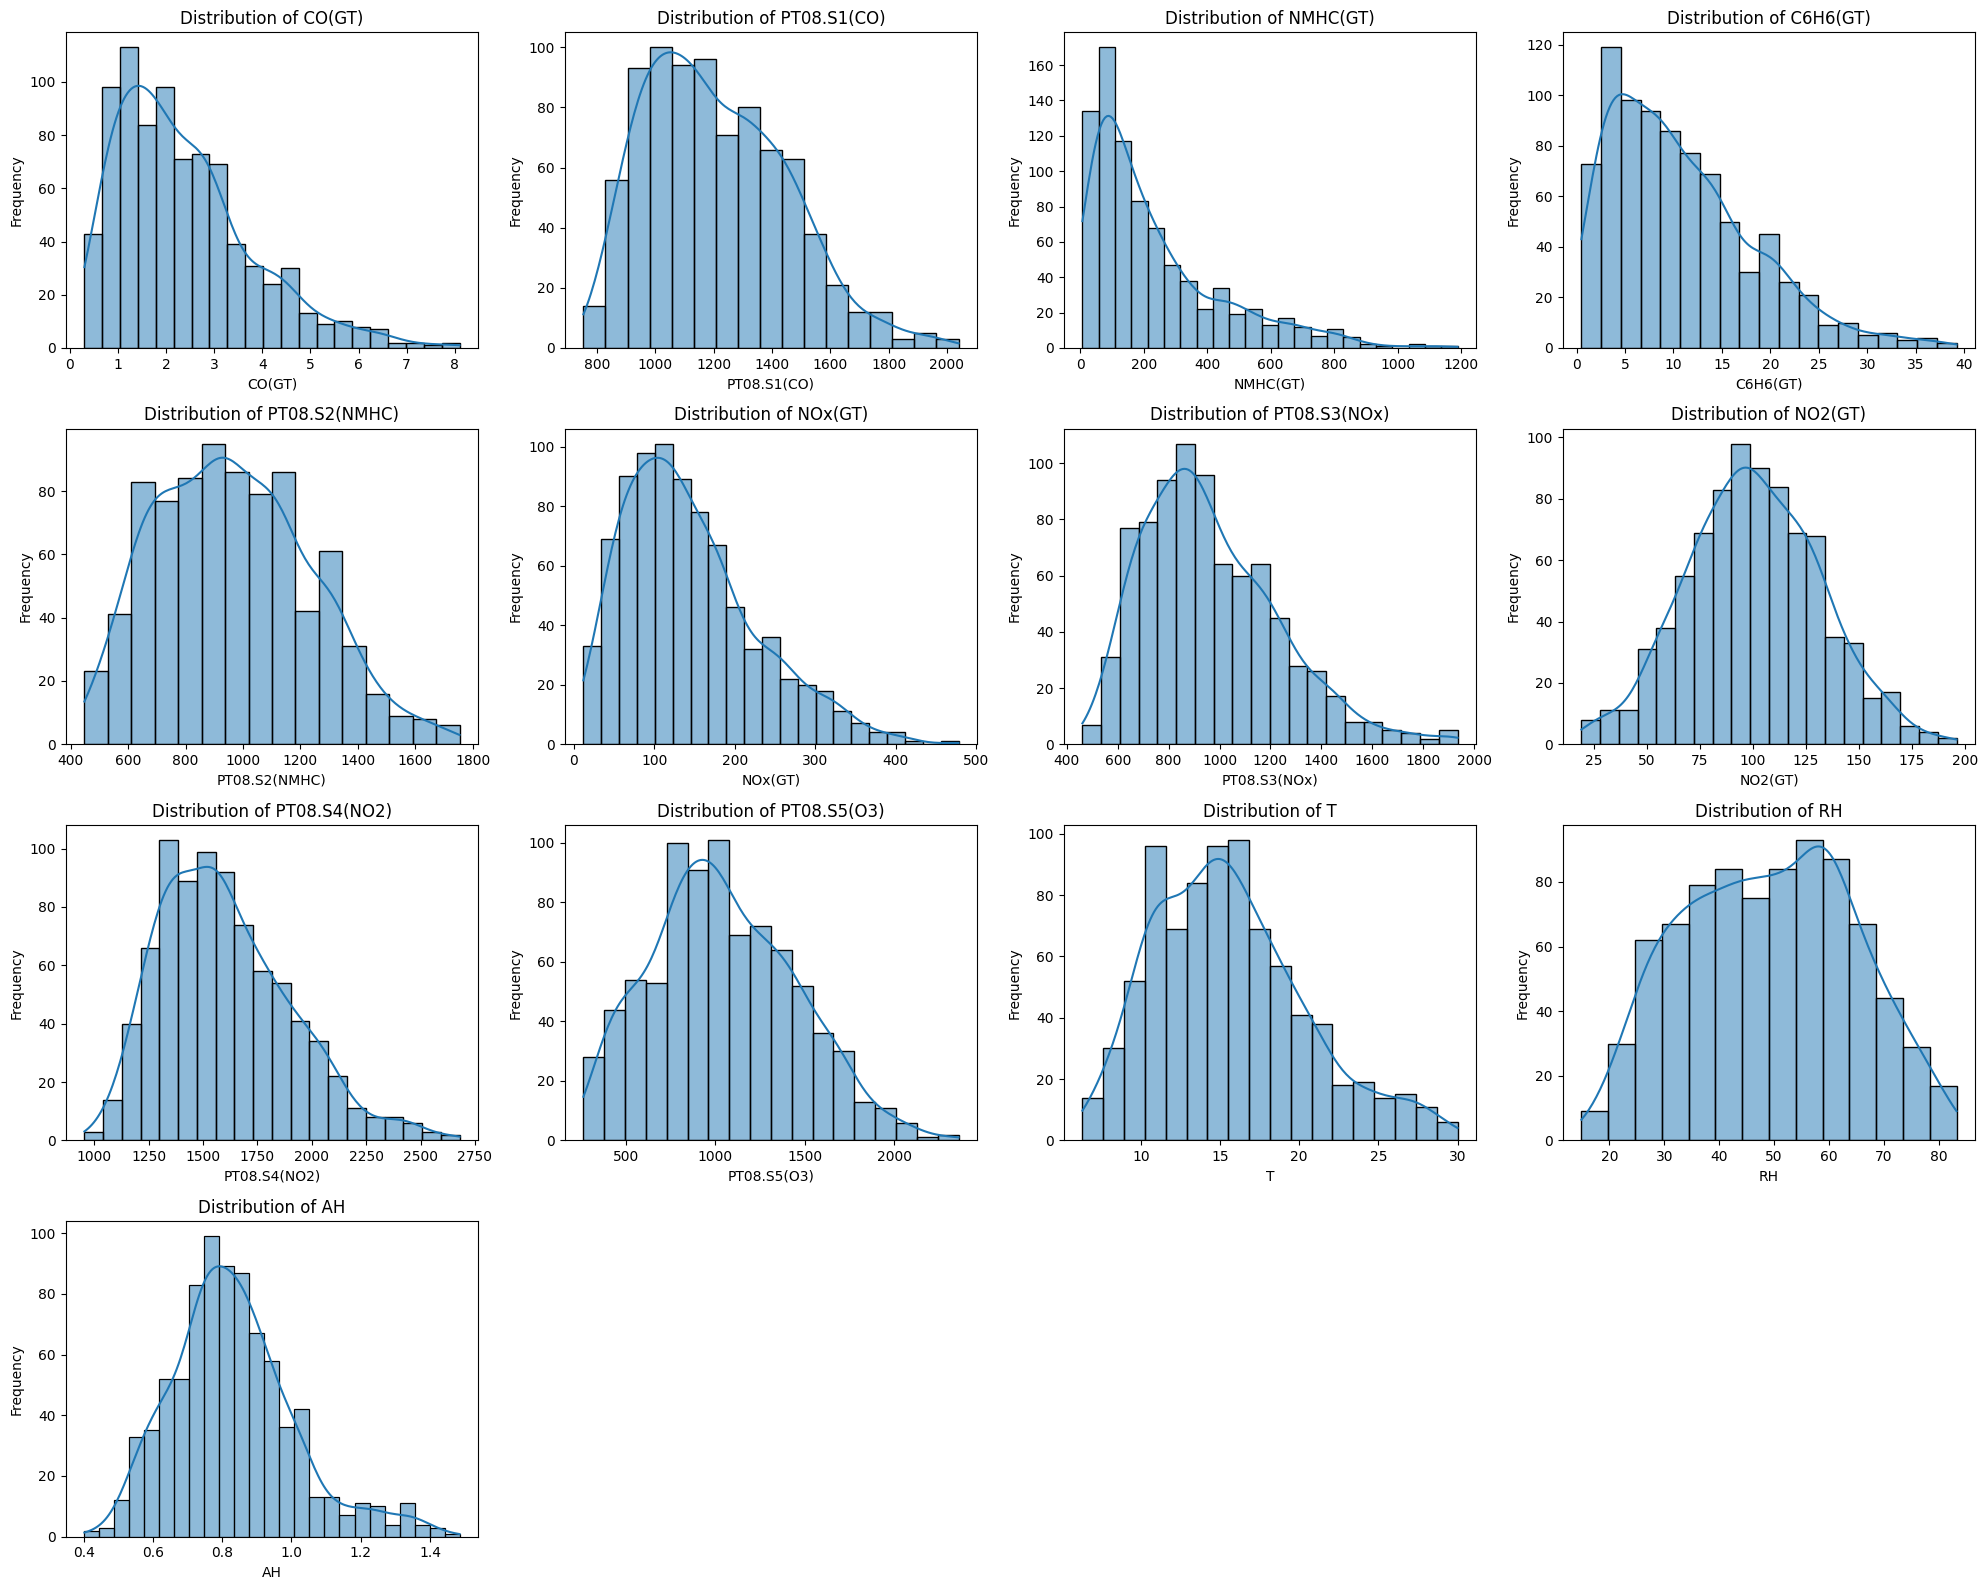

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'Date' and one-hot encoded 'Time' columns for individual feature distribution plots

features_to_plot = [col for col in df_encoded.columns
                    if col not in ['Date'] and not col.startswith('Time_')]

n_features = len(features_to_plot)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# scale variables

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
y = df_encoded['CO(GT)']
X = df_encoded.drop(['CO(GT)', 'Date'], axis=1) # Drop target and non-numeric 'Date' column
X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd
import seaborn as sns
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,Time_14.00.00,Time_15.00.00,Time_16.00.00,Time_17.00.00,Time_18.00.00,Time_19.00.00,Time_20.00.00,Time_21.00.00,Time_22.00.00,Time_23.00.00
count,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,...,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02,8.270000e+02
mean,-2.062035e-16,5.155086e-17,8.591811e-17,6.873448e-17,-1.718362e-17,-3.436724e-17,1.890198e-16,-3.608560e-16,5.155086e-17,-3.952233e-16,...,-1.073976e-17,4.081110e-17,6.819750e-17,7.034545e-17,1.825760e-17,1.879459e-17,1.772061e-17,1.879459e-17,1.825760e-17,1.825760e-17
std,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,...,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00,1.000605e+00
min,-1.882226e+00,-1.075309e+00,-1.385431e+00,-1.945878e+00,-1.607990e+00,-1.890089e+00,-2.581749e+00,-2.137044e+00,-1.957557e+00,-1.928807e+00,...,-2.102187e-01,-2.070632e-01,-2.133354e-01,-2.164150e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01
25%,-7.898311e-01,-7.393130e-01,-8.054200e-01,-7.966399e-01,-7.642656e-01,-7.311195e-01,-6.913465e-01,-7.650230e-01,-7.147232e-01,-7.675560e-01,...,-2.102187e-01,-2.070632e-01,-2.133354e-01,-2.164150e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01
50%,-1.484627e-01,-3.553176e-01,-2.254086e-01,-8.306091e-02,-1.895545e-01,-1.629235e-01,-4.003129e-02,-1.476961e-01,-9.205614e-02,-1.247206e-01,...,-2.102187e-01,-2.070632e-01,-2.133354e-01,-2.164150e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01
75%,7.122125e-01,4.198731e-01,5.434436e-01,6.624414e-01,5.318912e-01,6.310458e-01,6.907126e-01,6.053434e-01,6.856525e-01,5.595880e-01,...,-2.102187e-01,-2.070632e-01,-2.133354e-01,-2.164150e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01,-2.194589e-01
max,3.443201e+00,4.598223e+00,3.834671e+00,2.959039e+00,4.090209e+00,3.656408e+00,3.041802e+00,3.569506e+00,3.283850e+00,2.985773e+00,...,4.756950e+00,4.829444e+00,4.687454e+00,4.620752e+00,4.556661e+00,4.556661e+00,4.556661e+00,4.556661e+00,4.556661e+00,4.556661e+00


<Axes: >

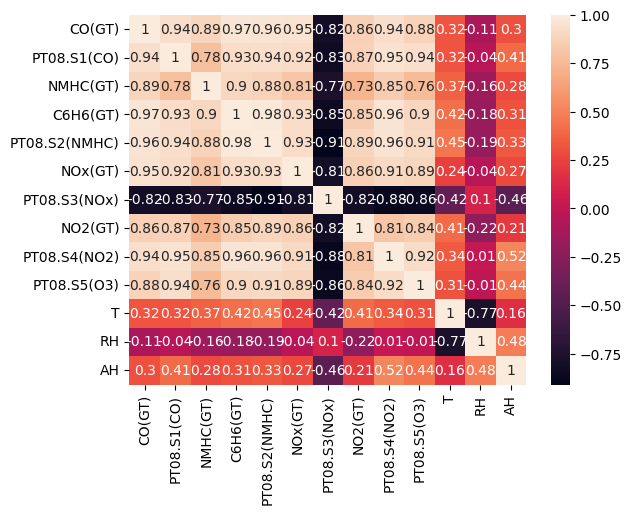

In [ ]:
correlation_matrix = df.corr(numeric_only=True).round(2)
# annot = True to print the values inside the square
sns.heatmap(data=correlation_matrix, annot=True)

In [ ]:
#Choose the features with highest correlation to CO(GT) since that is our target variable
features = ['C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)']

In [ ]:
X = X_scaled[features]

In [ ]:
# split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5)

In [ ]:
X_train.shape, X_test.shape

((661, 3), (166, 3))

**SGDRegressor Model**

In [ ]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(max_iter=1000, tol=1e-3)
sgd.fit(X_train, y_train)

SGDRegressor()

In [ ]:
sgd.coef_

array([0.52643361, 0.38134058, 0.49610002])

In [ ]:
sgd.intercept_

array([2.35429446])

In [ ]:
sgd.score(X_test, y_test)

0.9604545159928177

In [ ]:
#calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
y_pred = sgd.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
ev = explained_variance_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
mse, mae, ev, r2

(0.09005476545788135,
 0.21933407636942076,
 0.9604666167365252,
 0.9604545159928177)

In [ ]:
y_train_pred = sgd.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Default SGDRegressor — Train -> R2: {train_r2:.4f}, MSE: {train_mse:.4f}, MAE: {train_mae:.4f}")
print(f"Default SGDRegressor — Test  -> R2: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}")


Default SGDRegressor — Train -> R2: 0.9585, MSE: 0.0793, MAE: 0.2110
Default SGDRegressor — Test  -> R2: 0.9605, MSE: 0.0901, MAE: 0.2193


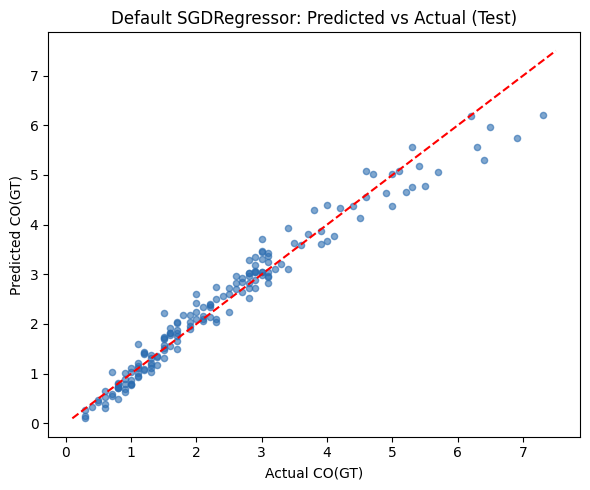

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_pred, alpha=0.6, s=20, color="#2b6cb0")
lims = [y_test.min() - 0.2, y_test.max() + 0.2]
ax.plot(lims, lims, "r--", lw=1.5)
ax.set_xlabel("Actual CO(GT)")
ax.set_ylabel("Predicted CO(GT)")
ax.set_title("Default SGDRegressor: Predicted vs Actual (Test)")

plt.tight_layout()
plt.show()

**Hypertuned Version of SGDRegressor**

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools

param_grid = {
    "penalty": ["l2", "l1", "elasticnet"],
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.15, 0.5, 0.85],
    "learning_rate": ["invscaling", "constant", "adaptive"],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))

sgd_log_rows = []
for combo in combos:
    params = dict(zip(keys, combo))
    model = SGDRegressor(
        max_iter=1000,
        tol=1e-3,
        eta0=0.01,          # needed for 'constant'/'invscaling' learning rates
        random_state=5,
        **params,
    )
    model.fit(X_train, y_train)
    y_pred_tmp = model.predict(X_test)

    sgd_log_rows.append({
        **params,
        "test_r2": r2_score(y_test, y_pred_tmp),
        "test_rmse": mean_squared_error(y_test, y_pred_tmp) ** 0.5,
        "test_mae": mean_absolute_error(y_test, y_pred_tmp),
    })

sgd_log_df = pd.DataFrame(sgd_log_rows).sort_values("test_r2", ascending=False).reset_index(drop=True)
sgd_log_df.to_csv("sgd_hyperparameter_log.csv", index=False)
print(f"Tried {len(sgd_log_df)} hyperparameter combinations. Log saved to sgd_hyperparameter_log.csv")
sgd_log_df.head(10)

Tried 135 hyperparameter combinations. Log saved to sgd_hyperparameter_log.csv


,penalty,alpha,l1_ratio,learning_rate,test_r2,test_rmse,test_mae
0,l1,0.0001,0.50,adaptive,0.965493,0.280324,0.200762
1,l1,0.0001,0.15,adaptive,0.965493,0.280324,0.200762
2,l1,0.0001,0.85,adaptive,0.965493,0.280324,0.200762
3,elasticnet,0.0001,0.85,adaptive,0.965491,0.280331,0.200768
4,elasticnet,0.0001,0.50,adaptive,0.965487,0.280348,0.200783
5,elasticnet,0.0001,0.15,adaptive,0.965482,0.280366,0.200798
6,l2,0.0001,0.15,adaptive,0.965481,0.280373,0.200804
7,l2,0.0001,0.85,adaptive,0.965481,0.280373,0.200804
8,l2,0.0001,0.50,adaptive,0.965481,0.280373,0.200804
9,l1,0.0010,0.85,adaptive,0.965448,0.280504,0.200748


In [ ]:
best_sgd_params = sgd_log_df.iloc[0][keys].to_dict()
# cast alpha/l1_ratio back to float (they may come back as numpy/py objects from the DataFrame row)
best_sgd_params["alpha"] = float(best_sgd_params["alpha"])
best_sgd_params["l1_ratio"] = float(best_sgd_params["l1_ratio"])

print("Best hyperparameters:", best_sgd_params)

sgd_tuned = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=5, **best_sgd_params)
sgd_tuned.fit(X_train, y_train)
y_pred_tuned = sgd_tuned.predict(X_test)

tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_rmse = mean_squared_error(y_test, y_pred_tuned) ** 0.5
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

print(f"Tuned SGDRegressor    R2: {tuned_r2:.4f}, RMSE: {tuned_rmse:.4f}, MAE: {tuned_mae:.4f}")

Best hyperparameters: {'penalty': 'l1', 'alpha': 0.0001, 'l1_ratio': 0.5, 'learning_rate': 'adaptive'}
Tuned SGDRegressor    R2: 0.9655, RMSE: 0.2803, MAE: 0.2008


In [ ]:
y_train_pred_tuned = sgd_tuned.predict(X_train)
tuned_train_r2 = r2_score(y_train, y_train_pred_tuned)
tuned_train_mse = mean_squared_error(y_train, y_train_pred_tuned)
tuned_train_mae = mean_absolute_error(y_train, y_train_pred_tuned)

print(f"Tuned SGDRegressor — Train -> R2: {tuned_train_r2:.4f}, MSE: {tuned_train_mse:.4f}, MAE: {tuned_train_mae:.4f}")
print(f"Tuned SGDRegressor — Test  -> R2: {tuned_r2:.4f}, RMSE: {tuned_rmse:.4f}, MAE: {tuned_mae:.4f}")


Tuned SGDRegressor — Train -> R2: 0.9618, MSE: 0.0730, MAE: 0.1972
Tuned SGDRegressor — Test  -> R2: 0.9655, RMSE: 0.2803, MAE: 0.2008


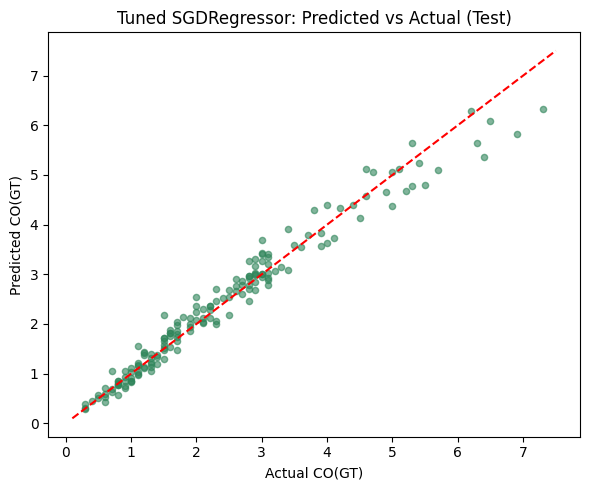

In [ ]:
fig, axes = plt.subplots(figsize=(6, 5))

axes.scatter(y_test, y_pred_tuned, alpha=0.6, s=20, color="#2f855a")
lims = [y_test.min() - 0.2, y_test.max() + 0.2]
axes.plot(lims, lims, "r--", lw=1.5)
axes.set_xlabel("Actual CO(GT)")
axes.set_ylabel("Predicted CO(GT)")
axes.set_title("Tuned SGDRegressor: Predicted vs Actual (Test)")

plt.tight_layout()
plt.show()

**OLS Model**

In [ ]:
import statsmodels.api as sm

In [ ]:
X_sm = df.drop('CO(GT)', axis=1)
y = df['CO(GT)']
features = ['C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)']

In [ ]:
X_sm = X_sm[features]

In [ ]:
X_sm.head()

,C6H6(GT),PT08.S2(NMHC),NOx(GT)
0,11.9,1046.0,166.0
1,9.4,955.0,103.0
2,9.0,939.0,131.0
3,9.2,948.0,172.0
4,6.5,836.0,131.0


In [ ]:
y.head()

,CO(GT)
0,2.6
1,2.0
2,2.2
3,2.2
4,1.6


In [ ]:
X_sm = sm.add_constant(X_sm)

In [ ]:
X_sm.head()

,const,C6H6(GT),PT08.S2(NMHC),NOx(GT)
0,1.0,11.9,1046.0,166.0
1,1.0,9.4,955.0,103.0
2,1.0,9.0,939.0,131.0
3,1.0,9.2,948.0,172.0
4,1.0,6.5,836.0,131.0


In [ ]:
X_sm_train, X_sm_test, y_sm_train, y_sm_test = train_test_split(X_sm, y, test_size = 0.2, random_state=5)

In [ ]:
mod = sm.OLS(y_sm_train, X_sm_train)

In [ ]:
res = mod.fit()

In [ ]:
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 CO(GT)   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     5628.
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:26:20   Log-Likelihood:                -66.216
No. Observations:                 661   AIC:                             140.4
Df Residuals:                     657   BIC:                             158.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4588      0.134      3.419

In [ ]:
y_sm_test_predict = res.predict(X_sm_test)

In [ ]:
sm.tools.eval_measures.rmse(y_sm_test, y_sm_test_predict)

np.float64(0.2679921844224405)

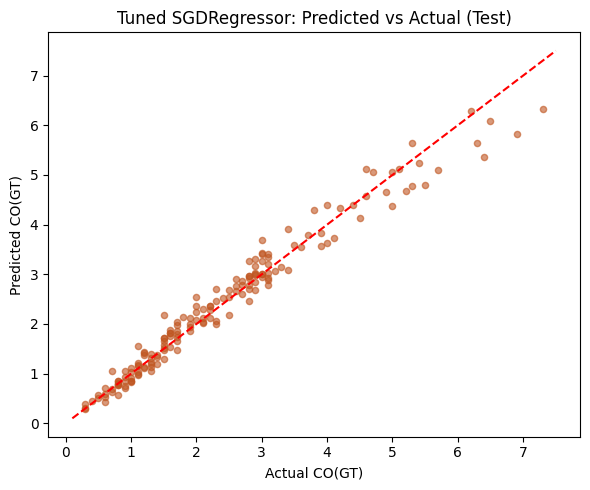

In [151]:
ig, axes = plt.subplots(figsize=(6, 5))

axes.scatter(y_test, y_pred_tuned, alpha=0.6, s=20, color="#c05621")
lims = [y_test.min() - 0.2, y_test.max() + 0.2]
axes.plot(lims, lims, "r--", lw=1.5)
axes.set_xlabel("Actual CO(GT)")
axes.set_ylabel("Predicted CO(GT)")
axes.set_title("Tuned SGDRegressor: Predicted vs Actual (Test)")

plt.tight_layout()
plt.show()


**Hypertuned Version for OLS**

In [ ]:
import numpy as np

reg_ols_rows = []
for alpha_ in [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]:
    for l1_wt in [0.0, 0.25, 0.5, 0.75, 1.0]:
        res_reg = mod.fit_regularized(alpha=alpha_, L1_wt=l1_wt)
        params_arr = np.asarray(res_reg.params)
        pred_test = X_sm_test.values @ params_arr

        reg_ols_rows.append({
            "alpha": alpha_,
            "L1_wt": l1_wt,
            "test_r2": r2_score(y_sm_test, pred_test),
            "test_rmse": mean_squared_error(y_sm_test, pred_test) ** 0.5,
        })

reg_ols_df = pd.DataFrame(reg_ols_rows).sort_values("test_r2", ascending=False).reset_index(drop=True)
reg_ols_df.to_csv("reg_ols_hyperparameter.csv", index=False)
print(f"Tried {len(reg_ols_df)} hyperparameter combinations. Log saved to reg_ols_hyperparameter.csv")
reg_ols_df.head(10)

Tried 30 hyperparameter combinations. Log saved to reg_ols_hyperparameter.csv


,alpha,L1_wt,test_r2,test_rmse
0,0.0100,1.00,0.969932,0.261670
1,0.0100,0.75,0.969927,0.261695
2,0.0100,0.50,0.969919,0.261731
3,0.0100,0.25,0.969909,0.261773
4,0.0010,1.00,0.969904,0.261793
5,0.0010,0.75,0.969901,0.261806
6,0.0010,0.50,0.969898,0.261819
7,0.0010,0.25,0.969895,0.261832
8,0.0001,1.00,0.969871,0.261939
9,0.0001,0.75,0.969870,0.261940


In [ ]:
best_alpha = float(reg_ols_df.iloc[0]["alpha"])
best_l1wt = float(reg_ols_df.iloc[0]["L1_wt"])
print(f"Best alpha: {best_alpha}, Best L1_wt: {best_l1wt}")

Best alpha: 0.01, Best L1_wt: 1.0


In [ ]:
res_tuned = mod.fit_regularized(alpha=best_alpha, L1_wt=best_l1wt)
tuned_params = np.asarray(res_tuned.params)
tuned_pred_test = X_sm_test.values @ tuned_params

In [ ]:
unreg_rmse = sm.tools.eval_measures.rmse(y_sm_test, y_sm_test_predict)
unreg_r2 = r2_score(y_sm_test, y_sm_test_predict)

tuned_rmse_ols = mean_squared_error(y_sm_test, tuned_pred_test) ** 0.5
tuned_r2_ols = r2_score(y_sm_test, tuned_pred_test)

In [ ]:
print(f"\nUnregularized OLS -> R2: {unreg_r2:.4f}, RMSE: {unreg_rmse:.4f}")
print(f"Regularized OLS   -> R2: {tuned_r2_ols:.4f}, RMSE: {tuned_rmse_ols:.4f}")

print("\nCoefficients (unregularized vs regularized):")
coef_compare = pd.DataFrame({
    "unregularized": res.params,
    "regularized": pd.Series(tuned_params, index=X_sm_train.columns),
})
coef_compare



Unregularized OLS -> R2: 0.9685, RMSE: 0.2680
Regularized OLS   -> R2: 0.9699, RMSE: 0.2617

Coefficients (unregularized vs regularized):


,unregularized,regularized
const,0.458779,0.518286
C6H6(GT),0.135294,0.153409
PT08.S2(NMHC),-0.000493,-0.000591
NOx(GT),0.006380,0.005247


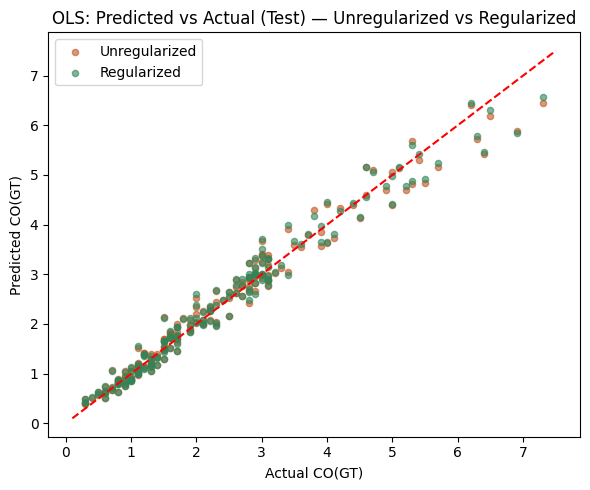

In [155]:
fig, axes = plt.subplots(figsize=(6, 5))

axes.scatter(y_sm_test, y_sm_test_predict, alpha=0.6, s=20, color="#c05621", label="Unregularized")
axes.scatter(y_sm_test, tuned_pred_test, alpha=0.6, s=20, color="#2f855a", label="Regularized")
lims = [y_sm_test.min() - 0.2, y_sm_test.max() + 0.2]
axes.plot(lims, lims, "r--", lw=1.5)
axes.set_xlabel("Actual CO(GT)")
axes.set_ylabel("Predicted CO(GT)")
axes.set_title("OLS: Predicted vs Actual (Test) — Unregularized vs Regularized")
axes.legend()

plt.tight_layout()
plt.show()